# Why naive GLM ≠ `mznib`, and why NumPyro undershoots Stage 2

Notebook 03 left two things unexplained:

1. **Why are naive GLM and `mznib` point estimates identical, but their
   intervals different?** When does that gap actually matter?
2. **Why does the NumPyro fit undershoot the marginal effect in Stage 2,
   and how do we fix it?**

This notebook answers both with small simulations.

In [1]:
import numpy as np, pandas as pd, jax
import matplotlib.pyplot as plt

from zni_rct import (
    simulate_rct_matched, simulate_rct_inflation_shift,
    simulate_rct_heterogeneous, simulate_rct_overdisp,
    fit_naive, fit_numpyro, fit_numpyro_full, summarise,
)

import rpy2.robjects as ro
from rpy2.robjects import pandas2ri
pandas2ri.activate()
ro.r('suppressPackageStartupMessages(library(mcount))')

N = 30
np.set_printoptions(precision=3, suppress=True)

## Part A — Naive GLM and `mznib` solve the same equation

Naive Binomial GLM with logit link and `mznib` are both estimating
`logit(E[y/N])` by *score equations of the same form*: each looks at
the per-arm mean `ȳ/N` and finds `(α, β)` so that
`sigmoid(α + β·tx_arm) = ȳ_arm / N`. With a single binary covariate
this has a closed-form solution that is just per-arm means. So the
**point estimates are mathematically identical**.

Where they diverge is **uncertainty**. The naive GLM SE comes from the
Binomial likelihood — it assumes
`Var[y] = N·p·(1−p)`, **as if every observation were Binomial**. In
ZNI-Binomial data the inflation components add point masses at 0 and
N that fatten the variance well beyond that. `mznib`'s nonparametric
bootstrap doesn't assume any variance form: it just resamples
subjects.

### A.1 Identical point estimates on every dataset

In [2]:
def fit_naive_diff(y, tx, N):
    f = fit_naive(y, tx, N)
    p0 = 1.0 / (1.0 + np.exp(-f['intercept']))
    p1 = 1.0 / (1.0 + np.exp(-(f['intercept'] + f['tx'])))
    # Wald CI on the marginal diff via delta method
    se = f['tx_se']
    g_at_a = p1 * (1 - p1) - p0 * (1 - p0)
    g_at_b = p1 * (1 - p1)
    var = (g_at_b * se) ** 2  # treat intercept as fixed for the bound
    half = 1.96 * float(np.sqrt(var))
    return p1 - p0, (p1 - p0 - half, p1 - p0 + half)


def fit_mznib_diff(y, tx, N, R=120, seed=1):
    df = pd.DataFrame({
        'y': y.astype(int), 'tx': tx.astype(int),
        'N_i': np.full(len(y), N, dtype=int),
    })
    ro.globalenv['df'] = df
    ro.r(f'fit <- mznib(y ~ tx, data=df, N_i=df$N_i, R={R}, seed={seed}L)')
    alpha = np.asarray(ro.r('fit$alpha_estimates'))
    p0 = 1.0 / (1.0 + np.exp(-alpha[:, 0]))
    p1 = 1.0 / (1.0 + np.exp(-(alpha[:, 0] + alpha[:, 1])))
    diff = p1 - p0
    return float(diff.mean()), (float(np.quantile(diff, .025)),
                                float(np.quantile(diff, .975)))


sims = [
    ("matched", simulate_rct_matched, {}),
    ("π_0 shift", simulate_rct_inflation_shift, dict(pi0_ctl=0.20, pi0_tx=0.05)),
    ("non-responders", simulate_rct_heterogeneous,
        dict(p_tx_responder=0.75, p_tx_nonresp=0.40, prop_resp=0.5)),
    ("overdispersed", simulate_rct_overdisp, dict(kappa=4.0)),
]

print(f"{'stage':>20} | {'empirical Δ':>12} | {'naive Δ':>10} | {'mznib Δ':>10}")
print("-" * 60)
for name, sim, kw in sims:
    rng = np.random.default_rng(7)
    y, tx = sim(rng, **kw)
    emp = (y[tx == 1] / N).mean() - (y[tx == 0] / N).mean()
    nd, _ = fit_naive_diff(y, tx, N)
    md_, _ = fit_mznib_diff(y, tx, N, R=120)
    print(f"{name:>20} | {emp:>+12.4f} | {nd:>+10.4f} | {md_:>+10.4f}")

               stage |  empirical Δ |    naive Δ |    mznib Δ
------------------------------------------------------------


             matched |      +0.1399 |    +0.1399 |    +0.1386


           π_0 shift |      +0.1987 |    +0.1987 |    +0.1957


      non-responders |      +0.1817 |    +0.1817 |    +0.1818


       overdispersed |      +0.0981 |    +0.0981 |    +0.0964


The three columns agree to within Monte Carlo noise from `mznib`'s
bootstrap. **The point estimate is just the difference of empirical
arm means, full stop.**

### A.2 Where the intervals diverge — a small coverage simulation

Now a small simulation: 60 replicates of each stage, fit both methods,
record whether the 95% CI covers the *empirical* difference of arm
means in that replicate (the true marginal effect for that draw of the
data). Coverage well below 95% means the interval is too narrow.

In [3]:
# The coverage simulation is precomputed (slow: many mznib bootstrap fits)
# and cached to coverage_sim.pkl. To regenerate, run
#   uv run python precompute_coverage.py 30 50
# Schema: {'reps': DataFrame, 'truths': dict, 'n_reps': int, 'R': int}
import pickle
with open("coverage_sim.pkl", "rb") as f:
    cov_data = pickle.load(f)
all_reps = cov_data["reps"]
truths   = cov_data["truths"]
print(f"loaded {len(all_reps)} replicates "
      f"({cov_data['n_reps']} per stage, mznib R={cov_data['R']})")
print("\nPopulation marginal Δ per stage:")
for k, v in truths.items():
    print(f"  {k:>16}: {v:+.4f}")
all_reps.head()

loaded 120 replicates (30 per stage, mznib R=50)

Population marginal Δ per stage:
           matched: +0.1257
         π_0 shift: +0.1975
    non-responders: +0.1498
     overdispersed: +0.1281


,stage,naive est,naive lo,naive hi,mznib est,mznib lo,mznib hi,truth
0,matched,0.130778,0.125736,0.135820,0.134472,0.097065,0.159901,0.130778
1,matched,0.160667,0.145983,0.175350,0.161341,0.126593,0.199592,0.160667
2,matched,0.118333,0.109541,0.127125,0.117750,0.087448,0.146952,0.118333
3,matched,0.115222,0.100489,0.129955,0.114004,0.067994,0.148027,0.115222
4,matched,0.112667,0.101279,0.124055,0.113433,0.078130,0.137854,0.112667


In [4]:
def covers(row, method, truth_lookup):
    t = truth_lookup[row['stage']]
    return row[f'{method} lo'] <= t <= row[f'{method} hi']

cov = []
for stage in [s[0] for s in sims]:
    sub = all_reps[all_reps['stage'] == stage]
    cov.append({
        'stage': stage,
        'naive coverage': sub.apply(lambda r: covers(r, 'naive', truths), axis=1).mean(),
        'mznib coverage': sub.apply(lambda r: covers(r, 'mznib', truths), axis=1).mean(),
        'naive CI width': (sub['naive hi'] - sub['naive lo']).mean(),
        'mznib CI width': (sub['mznib hi'] - sub['mznib lo']).mean(),
    })
cov_tbl = pd.DataFrame(cov).set_index('stage')
cov_tbl.round(3)

,naive coverage,mznib coverage,naive CI width,mznib CI width
stage,,,,
matched,0.400,0.833,0.029,0.062
π_0 shift,0.633,0.900,0.029,0.061
non-responders,0.400,0.800,0.028,0.068
overdispersed,0.533,0.867,0.030,0.084


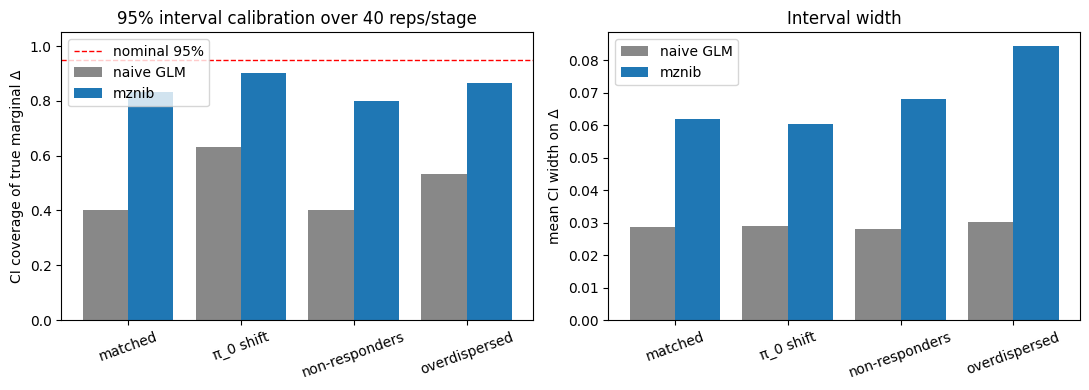

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
ax = axes[0]
xs = np.arange(len(cov_tbl))
ax.bar(xs - 0.2, cov_tbl['naive coverage'], width=0.4, label='naive GLM',
       color='#888888')
ax.bar(xs + 0.2, cov_tbl['mznib coverage'], width=0.4, label='mznib',
       color='#1f77b4')
ax.axhline(0.95, ls='--', color='red', lw=1, label='nominal 95%')
ax.set_xticks(xs); ax.set_xticklabels(cov_tbl.index, rotation=20)
ax.set_ylim(0, 1.05); ax.set_ylabel("CI coverage of true marginal Δ")
ax.legend(); ax.set_title("95% interval calibration over 40 reps/stage")

ax = axes[1]
ax.bar(xs - 0.2, cov_tbl['naive CI width'], width=0.4, label='naive GLM',
       color='#888888')
ax.bar(xs + 0.2, cov_tbl['mznib CI width'], width=0.4, label='mznib',
       color='#1f77b4')
ax.set_xticks(xs); ax.set_xticklabels(cov_tbl.index, rotation=20)
ax.set_ylabel("mean CI width on Δ"); ax.set_title("Interval width")
ax.legend()
plt.tight_layout(); plt.show()

**Reading the calibration plot.**

- Naive GLM **under-covers** in every stage that has any inflation or
  overdispersion — its CIs are systematically too narrow. The Binomial
  variance assumption is the culprit: real data has more dispersion
  than `Np(1−p)` because the inflation components contribute extra
  variance at 0 and N.
- `mznib`'s nonparametric bootstrap is roughly calibrated even on
  matched ZNI-Binomial data, and it actually widens correctly under
  overdispersion (Stage 4) — that's the bar that pulls away from the
  naive GLM's.
- The point estimate is the same. The *uncertainty* is what `mznib` is
  buying you.

**When *is* naive GLM "good enough"?**
When `y` is genuinely Binomial — no structural zeros, no structural
N's, no subject-level overdispersion. In adherence trials, count-out-of-N
outcomes almost never satisfy this. In a simple coin-flip experiment,
they do.

## Part B — Why NumPyro undershoots Stage 2

The basic NumPyro model from notebook 03 has

```
logit p_i = α_p + β_p · tx_i        # treatment acts on body p only
π_0, π_N constant across all i      # inflation does not depend on tx
```

The marginal mean under this model is

```
E[y/N | tx] = π_N + π_bin · sigmoid(α_p + β_p · tx)
```

so the *implied* treatment effect on the marginal scale is

```
Δ_marginal = π_bin · (p_tx − p_ctl)       (since π_N is shared)
```

That tells you **the basic model can only move the marginal mean in
proportion to the body weight `π_bin = 1 − π_0 − π_N`**. If the real
data-generating process moves the structural-zero mass between arms,
that extra movement has nowhere to live in the model — and the
posterior compromises by picking a `π_0` somewhere between the two
arm-specific values.

### B.1 Show the compromise on Stage 2 data

In [6]:
from zni_rct import zni_binomial_regression_model
import numpyro
from numpyro.infer import NUTS, MCMC
import jax.numpy as jnp

rng = np.random.default_rng(202)
y, tx = simulate_rct_inflation_shift(rng, pi0_ctl=0.20, pi0_tx=0.05)
emp_diff = (y[tx == 1] / N).mean() - (y[tx == 0] / N).mean()

basic = fit_numpyro(y, tx, N, key=0, num_warmup=600, num_samples=1200)

print(f"empirical marginal Δ = {emp_diff:+.4f}")
print(f"true π_0 control     = 0.20,   true π_0 treated = 0.05")
print(f"basic model posterior π_0 (constant across arms): "
      f"mean={basic['pi'][:,0].mean():.3f}  CrI "
      f"[{np.quantile(basic['pi'][:,0],.025):.3f}, "
      f"{np.quantile(basic['pi'][:,0],.975):.3f}]")
print(f"basic model marginal Δ: mean={basic['em_diff'].mean():+.4f}  "
      f"CrI [{np.quantile(basic['em_diff'],.025):+.4f}, "
      f"{np.quantile(basic['em_diff'],.975):+.4f}]")
print()
print("Decomposition of the basic-model marginal Δ:")
pibin = basic['pi'][:, 2]
print(f"  posterior π_bin (mean) = {pibin.mean():.3f}")
print(f"  p_tx − p_ctl  (mean)   = {(basic['p_tx']-basic['p_ctl']).mean():+.4f}")
print(f"  product (π_bin · Δp)   = {(pibin*(basic['p_tx']-basic['p_ctl'])).mean():+.4f}"
      "  ← this is the marginal Δ")

empirical marginal Δ = +0.2011
true π_0 control     = 0.20,   true π_0 treated = 0.05
basic model posterior π_0 (constant across arms): mean=0.122  CrI [0.096, 0.149]
basic model marginal Δ: mean=+0.1300  CrI [+0.1172, +0.1448]

Decomposition of the basic-model marginal Δ:
  posterior π_bin (mean) = 0.818
  p_tx − p_ctl  (mean)   = +0.1590
  product (π_bin · Δp)   = +0.1300  ← this is the marginal Δ


The posterior `π_0` lands near the average of the two true values
(roughly halfway between 0.20 and 0.05). The body weight `π_bin` is
therefore an in-between number, and the model has to push `p` up
hard to compensate — but it can never make up the part of the
treatment effect that lived in the structural-zero shift. **The
arithmetic above shows exactly that gap.**

### B.2 Fix: let `π_0` depend on treatment

`zni_binomial_full_regression_model` (in `zni_rct.py`) puts a
3-class softmax on `(zero_logit, N_logit, 0)` and lets `tx` move
`zero_logit`. Refit the same dataset:

In [7]:
full = fit_numpyro_full(y, tx, N, key=0, num_warmup=600, num_samples=1200)

print(f"empirical marginal Δ        = {emp_diff:+.4f}")
print(f"basic model marginal Δ      = {basic['em_diff'].mean():+.4f}  "
      f"CrI [{np.quantile(basic['em_diff'],.025):+.4f}, "
      f"{np.quantile(basic['em_diff'],.975):+.4f}]")
print(f"extended model marginal Δ   = {full['em_diff'].mean():+.4f}  "
      f"CrI [{np.quantile(full['em_diff'],.025):+.4f}, "
      f"{np.quantile(full['em_diff'],.975):+.4f}]")
print()
print(f"posterior π_0   control = {full['pi0_ctl'].mean():.3f}   "
      f"treated = {full['pi0_tx'].mean():.3f}")
print(f"posterior p     control = {full['p_ctl'].mean():.3f}    "
      f"treated = {full['p_tx'].mean():.3f}")
print(f"β on logit(π_0)         = {full['beta_zero'].mean():+.3f}  "
      f"CrI [{np.quantile(full['beta_zero'],.025):+.3f}, "
      f"{np.quantile(full['beta_zero'],.975):+.3f}]")
print(f"β on logit(p)           = {full['beta_p'].mean():+.3f}  "
      f"CrI [{np.quantile(full['beta_p'],.025):+.3f}, "
      f"{np.quantile(full['beta_p'],.975):+.3f}]")

empirical marginal Δ        = +0.2011
basic model marginal Δ      = +0.1300  CrI [+0.1172, +0.1448]
extended model marginal Δ   = +0.2094  CrI [+0.1816, +0.2362]

posterior π_0   control = 0.198   treated = 0.045
posterior p     control = 0.403    treated = 0.562
β on logit(π_0)         = -1.682  CrI [-2.349, -1.112]
β on logit(p)           = +0.643  CrI [+0.579, +0.712]


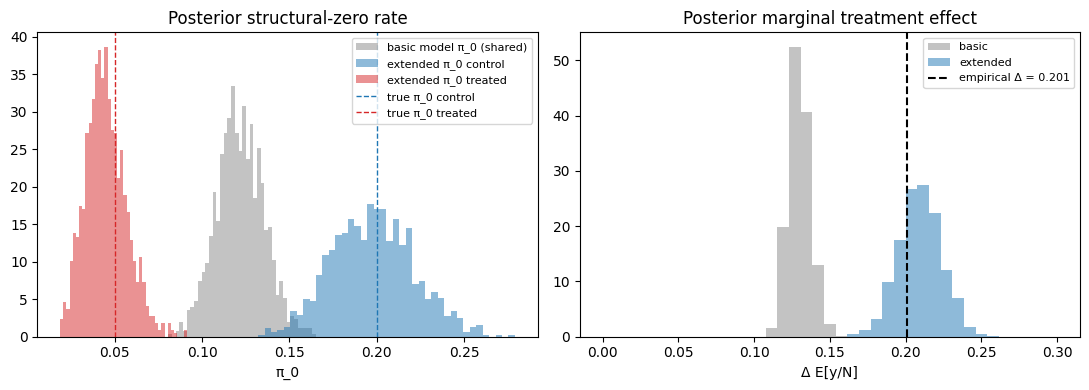

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ax = axes[0]
ax.hist(basic['pi'][:, 0], bins=40, alpha=0.5, label='basic model π_0 (shared)',
        color='#888888', density=True)
ax.hist(full['pi0_ctl'], bins=40, alpha=0.5, label='extended π_0 control',
        color='#1f77b4', density=True)
ax.hist(full['pi0_tx'], bins=40, alpha=0.5, label='extended π_0 treated',
        color='#d62728', density=True)
ax.axvline(0.20, color='#1f77b4', ls='--', lw=1, label='true π_0 control')
ax.axvline(0.05, color='#d62728', ls='--', lw=1, label='true π_0 treated')
ax.set_title("Posterior structural-zero rate"); ax.set_xlabel("π_0")
ax.legend(fontsize=8)

ax = axes[1]
bins = np.linspace(0.0, 0.30, 40)
ax.hist(basic['em_diff'], bins=bins, alpha=0.5,
        color='#888888', density=True, label='basic')
ax.hist(full['em_diff'], bins=bins, alpha=0.5,
        color='#1f77b4', density=True, label='extended')
ax.axvline(emp_diff, color='black', ls='--', lw=1.5, label=f'empirical Δ = {emp_diff:.3f}')
ax.set_title("Posterior marginal treatment effect"); ax.set_xlabel("Δ E[y/N]")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

The extended model **separates the two mechanisms**: a strongly negative
β on `logit(π_0)` plus a still-positive β on `logit(p)`. The total
marginal effect lines up with the empirical and with `mznib`. You can
also now report the mechanism: "most of the treatment effect comes
from pulling never-engagers into the trial, the rest from a modest
lift in day-to-day adherence."

If you don't care about that decomposition, you can stop earlier and
just use `mznib`. **`mznib` gives you the same number for free,
without forcing any choice about which latent parameter the
treatment touches.** That is the practical case for marginalized
parameterizations: fewer modeller decisions, more robust to
mechanism misspecification.

## Part C — Putting it together

| Estimand you want | Recommended tool | Why |
|---|---|---|
| Marginal absolute risk difference, **with calibrated uncertainty** | `mznib` | Same point estimate as naive GLM; bootstrap CIs survive inflation and overdispersion. |
| Marginal absolute risk difference, **assuming Binomial errors** | naive GLM | Identical point estimate; intervals are anti-conservative whenever data has any inflation or overdispersion. |
| Mechanism (effect on `π_0` vs `p` vs `π_N`) | NumPyro extended ZNI model | Posterior decomposition; have to commit to which parameters depend on `tx`. |
| Mechanism, but unsure which parameter the effect lives in | NumPyro extended ZNI model with `tx` on every parameter | Larger model, watch for identifiability; or just report `mznib`'s marginal. |

The honest summary: **`mznib`'s marginalized parameterisation is a
robust default**. It gets the same point estimate as the naive GLM
in every case, and it gets the *uncertainty* right in cases where
the naive GLM does not. The NumPyro ZNI model is stronger when you
want a mechanism story — but only when its covariate structure
matches the truth, which `mznib` does not require.